In [1]:
import h5py
import numpy as np
import spacy
from scipy.special import softmax
from utils import text_utils
import pandas as pd
import pickle

nlp = spacy.load("en_core_web_sm")

object_stimuli_path = "../data/stimuli/wilcox2022_embed4_object_gap.csv"

# heuristic: DET or PRON or PUNCT -> no_gap, everything else -> gap
NO_GAP_POS = {'DET', 'PRON', 'PUNCT'}

def get_gap_probabilities(sentence_starts, hdf5_path, n_samples=100):
    """
    For each sentence start, computes the probability of gap vs no_gap
    by sampling next tokens from an lm-zoo hdf5 file and applying the POS heuristic.
    
    Args:
        sentence_starts: dict of {original_idx: {sentence_start, condition, levels_of_embedding}}
        hdf5_path: path to hdf5 file of next-token predictions
        n_samples: number of tokens to sample from the distribution
    
    Returns:
        same dict with added keys: p_no_gap, p_gap, predicted
    """
    
    with h5py.File(hdf5_path, 'r') as f:
        vocab = [token.decode('utf-8') for token in f['vocabulary'][:]]
        original_indices = list(sentence_starts.keys())
        
        for seq_idx, original_idx in enumerate(original_indices):
            entry = sentence_starts[original_idx]
            
            sent = f['sentence'][str(seq_idx)]
            log_probs = sent['predictions'][-1]
            probs = softmax(log_probs).astype(float)
            probs = probs / probs.sum()
            
            sampled_indices = np.random.choice(len(probs), size=n_samples, p=probs)
            
            gap_count = 0
            no_gap_count = 0
            
            for token_idx in sampled_indices:
                token = vocab[token_idx].replace('Ġ', ' ').strip()
                doc = nlp(entry['sentence_start'] + ' ' + token)
                pos = doc[-1].pos_
                
                if pos in NO_GAP_POS:
                    no_gap_count += 1
                else:
                    gap_count += 1
            
            entry['gap_count'] = gap_count
            entry['no_gap_count'] = no_gap_count
    
    return sentence_starts

/home/marrsia/.local/lib/python3.8/site-packages/thinc/compat.py:36: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  hasattr(torch, "has_mps")
/home/marrsia/.local/lib/python3.8/site-packages/thinc/compat.py:37: UserWarning: 'has_mps' is deprecated, please use 'torch.backends.mps.is_built()'
  and torch.has_mps  # type: ignore[attr-defined]


In [2]:
def compute_and_show_results(stimuli_path, probabilities_path, gap_type, save_file = None):
    sentence_starts = text_utils.build_sentence_starts_for_sampling(stimuli_path, gap_type)
    sentence_starts = get_gap_probabilities(sentence_starts, probabilities_path)

    rows = []
    for sentence_id, entry in sentence_starts.items():
        expected = 'no_gap' if entry['condition'].endswith('no_gap') else 'gap'
        n_samples = entry['gap_count'] + entry['no_gap_count']
        
        # each sampled token is a separate prediction
        for _ in range(entry['gap_count']):
            rows.append({
                'sentence_id':     sentence_id,
                'condition':       entry['condition'],
                'embedding_level': entry['levels_of_embedding'],
                'expected':        expected,
                'predicted':       'gap',
            })
        for _ in range(entry['no_gap_count']):
            rows.append({
                'sentence_id':     sentence_id,
                'condition':       entry['condition'],
                'embedding_level': entry['levels_of_embedding'],
                'expected':        expected,
                'predicted':       'no_gap',
            })

    df_results = pd.DataFrame(rows)
    df_results['correct'] = df_results['expected'] == df_results['predicted']
    df_results['error'] = ~df_results['correct']
    
    by_condition      = df_results.groupby('condition')['error'].mean().round(3)
    by_embedding      = df_results.groupby('embedding_level')['error'].mean().round(3)
    by_condition_emb  = df_results.groupby(['condition', 'embedding_level'])['error'].mean().round(3).unstack()

    print("\n=== MEAN ERROR RATE BY CONDITION ===")
    print(df_results.groupby('condition')['error'].mean().round(3))

    print("\n=== MEAN ERROR RATE BY EMBEDDING LEVEL ===")
    print(df_results.groupby('embedding_level')['error'].mean().round(3))

    print("\n=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===")
    print(df_results.groupby(['condition', 'embedding_level'])['error'].mean().round(3).unstack())

    tp = ((df_results['expected'] == 'gap')    & (df_results['predicted'] == 'gap')).sum()
    fp = ((df_results['expected'] == 'no_gap') & (df_results['predicted'] == 'gap')).sum()
    tn = ((df_results['expected'] == 'no_gap') & (df_results['predicted'] == 'no_gap')).sum()
    fn = ((df_results['expected'] == 'gap')    & (df_results['predicted'] == 'no_gap')).sum()

    confusion = pd.DataFrame(
        [[tp, fn], [fp, tn]],
        index   = pd.Index(['predicted gap',    'predicted no_gap'], name=''),
        columns = pd.Index(['actual gap', 'actual no_gap'],          name='')
    )

    print("\n=== CONFUSION MATRIX (n=100 samples per sentence) ===")
    print(confusion)
    print(f"\n  precision : {tp / (tp + fp):.3f}  (of predicted gaps, how many were real)")
    print(f"  recall    : {tp / (tp + fn):.3f}  (of real gaps, how many were predicted)")
    print(f"  accuracy  : {(tp + tn) / len(df_results):.3f}")
    
    if save_file:
        filehandler =  open(save_file, 'wb')
        pickle.dump(df_results, filehandler)
    
    return {
        'df':                df_results,
        'by_condition':      by_condition,
        'by_embedding':      by_embedding,
        'by_condition_emb':  by_condition_emb,
        'confusion':         confusion,
        'tp': tp, 'fp': fp, 'tn': tn, 'fn': fn,
        'precision': tp / (tp + fp),
        'recall':    tp / (tp + fn),
        'accuracy':  (tp + tn) / len(df_results),
    }

In [3]:
pwd

'/home/marrsia/UCL_dissertation/ucl-fgd/notebooks'

## Results for gpt2

In [4]:
gpt2_results = compute_and_show_results(
    object_stimuli_path, 
    "../data/model_outputs/distributions/gpt2_wilcox2022_embed4_object_gap.hdf5", 
    gap_type = "object",
    save_file = "../data/model_outputs/distributions/gpt2_wilcox2022_embed4_object_gap_continuation_results"
)


=== MEAN ERROR RATE BY CONDITION ===
condition
+wh_gap       0.556
-wh_no_gap    0.311
Name: error, dtype: float64

=== MEAN ERROR RATE BY EMBEDDING LEVEL ===
embedding_level
0    0.404
1    0.405
2    0.445
3    0.454
4    0.460
Name: error, dtype: float64

=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===
embedding_level      0      1      2      3      4
condition                                         
+wh_gap          0.458  0.524  0.604  0.597  0.597
-wh_no_gap       0.351  0.286  0.285  0.311  0.323

=== CONFUSION MATRIX (n=100 samples per sentence) ===
                  actual gap  actual no_gap
                                           
predicted gap          11988          15012
predicted no_gap        8399          18601

  precision : 0.588  (of predicted gaps, how many were real)
  recall    : 0.444  (of real gaps, how many were predicted)
  accuracy  : 0.566


In [18]:
with open("../data/model_outputs/distributions/ngram_wilcox2022_embed4_object_gap_continuation_results", 'rb') as pickle_file:
    results = pickle.load(pickle_file)
    results.to_csv("../data/model_outputs/distributions/ngram_wilcox2022_embed4_object_gap_continuation_results.csv")

results

,sentence_id,condition,embedding_level,expected,predicted,correct,error
0,1,-wh_no_gap,0,no_gap,gap,False,True
1,1,-wh_no_gap,0,no_gap,gap,False,True
2,1,-wh_no_gap,0,no_gap,gap,False,True
3,1,-wh_no_gap,0,no_gap,gap,False,True
4,1,-wh_no_gap,0,no_gap,gap,False,True
...,...,...,...,...,...,...,...
53995,1078,+wh_gap,4,gap,gap,True,False
53996,1078,+wh_gap,4,gap,gap,True,False
53997,1078,+wh_gap,4,gap,gap,True,False
53998,1078,+wh_gap,4,gap,gap,True,False


## Results for grnn

In [6]:
grnn_results = compute_and_show_results(
    object_stimuli_path, 
    "../data/model_outputs/distributions/grnn_wilcox2022_embed4_object_gap.hdf5", 
    gap_type = "object",
    save_file = "../data/model_outputs/distributions/grnn_wilcox2022_embed4_object_gap_continuation_results"
)


=== MEAN ERROR RATE BY CONDITION ===
condition
+wh_gap       0.634
-wh_no_gap    0.290
Name: error, dtype: float64

=== MEAN ERROR RATE BY EMBEDDING LEVEL ===
embedding_level
0    0.429
1    0.454
2    0.452
3    0.491
4    0.486
Name: error, dtype: float64

=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===
embedding_level      0      1      2      3      4
condition                                         
+wh_gap          0.552  0.623  0.627  0.692  0.678
-wh_no_gap       0.305  0.285  0.278  0.290  0.294

=== CONFUSION MATRIX (n=100 samples per sentence) ===
                  actual gap  actual no_gap
                                           
predicted gap           9874          17126
predicted no_gap        7838          19162

  precision : 0.557  (of predicted gaps, how many were real)
  recall    : 0.366  (of real gaps, how many were predicted)
  accuracy  : 0.538


## Results for ngram
Ngram is a very simple model that does not have a mechanism for long distance dependencies, it only considers the previous 5 tokens. As a result the 50% accuracy is expected.

In [7]:
ngram_results = compute_and_show_results(
    object_stimuli_path, 
    "../data/model_outputs/distributions/ngram_wilcox2022_embed4_object_gap.hdf5", 
    gap_type = "object",
    save_file = "../data/model_outputs/distributions/ngram_wilcox2022_embed4_object_gap_continuation_results"
)


=== MEAN ERROR RATE BY CONDITION ===
condition
+wh_gap       0.005
-wh_no_gap    0.995
Name: error, dtype: float64

=== MEAN ERROR RATE BY EMBEDDING LEVEL ===
embedding_level
0    0.500
1    0.500
2    0.500
3    0.500
4    0.501
Name: error, dtype: float64

=== MEAN ERROR RATE BY CONDITION x EMBEDDING LEVEL ===
embedding_level      0      1      2      3      4
condition                                         
+wh_gap          0.006  0.005  0.006  0.006  0.005
-wh_no_gap       0.994  0.994  0.995  0.995  0.996

=== CONFUSION MATRIX (n=100 samples per sentence) ===
                  actual gap  actual no_gap
                                           
predicted gap          26857            143
predicted no_gap       26866            134

  precision : 0.500  (of predicted gaps, how many were real)
  recall    : 0.995  (of real gaps, how many were predicted)
  accuracy  : 0.500


## Visualisations

### error rate by model x condition

In [8]:
import matplotlib.pyplot as plt

def plot_error_rate_by_model_and_condition(results_dict):
    models     = list(results_dict.keys())
    conditions = sorted(next(iter(results_dict.values()))['by_condition'].index)

    n_models     = len(models)
    n_conditions = len(conditions)
    x            = np.arange(n_conditions)
    width        = 0.5 / n_models
    offsets      = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width
    colors       = ['#5bbcd6', '#f98400', '#00a08a', '#ff0000'][:n_models]

    fig, ax = plt.subplots(figsize=(7, 5))

    for i, model in enumerate(models):
        error_rates = [results_dict[model]['by_condition'].get(c, np.nan) for c in conditions]
        bars = ax.bar(x + offsets[i], error_rates, width, label=model, color=colors[i], alpha=0.85)

        for bar, rate in zip(bars, error_rates):
            if not np.isnan(rate):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    model,
                    ha='left', va='bottom',
                    fontsize=9, rotation=45,
                    color='black'
                )

    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=15, ha='right')
    ax.set_ylabel('Mean Error Rate')
    ax.set_xlabel('Condition')
    ax.set_title('Mean Error Rate by Model and Condition')
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

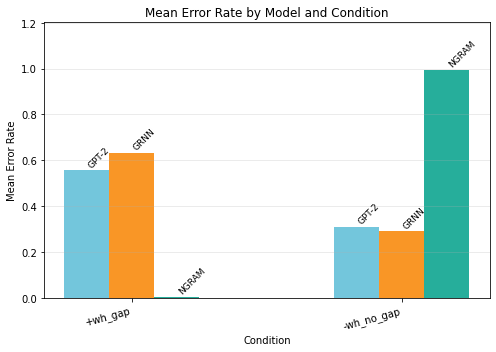

In [9]:
plot_error_rate_by_model_and_condition({
    'GPT-2': gpt2_results,
    'GRNN':  grnn_results,
    'NGRAM':ngram_results
})

### error rate by model x embedding level

In [10]:
def plot_error_rate_by_model_and_embedding(results_dict):
    """
    Plots mean error rate by model and embedding level as a grouped bar chart.

    Args:
        results_dict: dict of {model_name: results} where results is the
                      dict returned by compute_and_show_results
    """
    models           = list(results_dict.keys())
    embedding_levels = sorted(next(iter(results_dict.values()))['by_embedding'].index)

    n_models         = len(models)
    n_levels         = len(embedding_levels)
    x                = np.arange(n_levels)
    width            = 0.5 / n_models
    offsets          = np.linspace(-(n_models - 1) / 2, (n_models - 1) / 2, n_models) * width
    colors           = ['#5bbcd6', '#f98400', '#00a08a', '#ff0000'][:n_models]

    fig, ax = plt.subplots(figsize=(10, 7))

    for i, model in enumerate(models):
        error_rates = [results_dict[model]['by_embedding'].get(lvl, np.nan) for lvl in embedding_levels]
        bars = ax.bar(x + offsets[i], error_rates, width, color=colors[i], alpha=0.85)

        for bar, rate in zip(bars, error_rates):
            if not np.isnan(rate):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    model,
                    ha='left', va='bottom',
                    fontsize=9, rotation=45,
                    color='black'
                )

    ax.set_xticks(x)
    ax.set_xticklabels([f'embedding {l}' for l in embedding_levels])
    ax.set_ylabel('Mean Error Rate')
    ax.set_xlabel('Embedding Level')
    ax.set_title('Mean Error Rate by Model and Embedding Level')
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)
    ax.legend().set_visible(False)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.savefig('../data/images/sampling_accuracy.png', dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


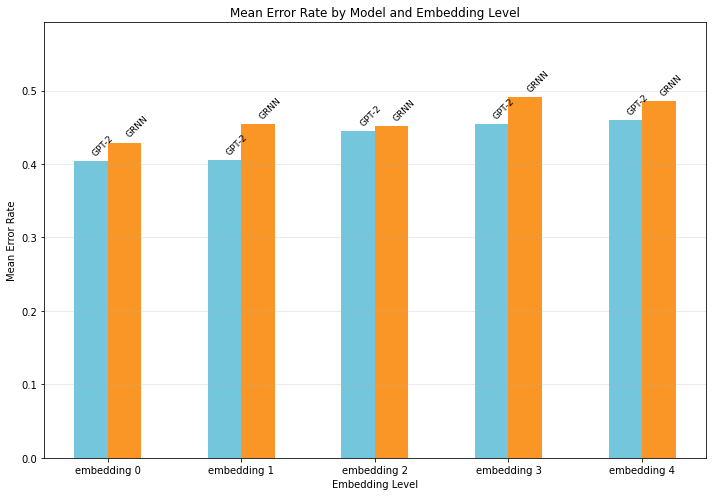

In [11]:
plot_error_rate_by_model_and_embedding({
    'GPT-2': gpt2_results,
    'GRNN':  grnn_results,
})

In [12]:
def plot_error_rate_by_model_embedding_and_condition(
    results_dict, conditions=None, condition_labels=None, embedding_levels=None,
):
    """
    Plots mean error rate split by model, embedding level, and condition.
    One color per model; conditions differentiated by hatch pattern.
    Within each embedding level, bars are grouped by model, with conditions side by side.

    Args:
        results_dict: dict of {model_name: results} where results is the
                      dict returned by compute_and_show_results
        conditions: list of condition strings to include, defaults to all
                    found in by_condition_emb
        condition_labels: display names for conditions, defaults to conditions
        embedding_levels: list of embedding levels to include, defaults to all
    """
    models       = list(results_dict.keys())
    first_emb_df = next(iter(results_dict.values()))['by_condition_emb']

    if conditions is None:
        conditions = sorted(first_emb_df.index)
    if condition_labels is None:
        condition_labels = conditions
    if embedding_levels is None:
        embedding_levels = sorted(first_emb_df.columns)

    n_models     = len(models)
    n_conditions = len(conditions)
    n_levels     = len(embedding_levels)
    n_bars       = n_models * n_conditions  # bars per embedding level

    # one color per model
    model_colors = ['#5bbcd6', '#f98400', '#00a08a', '#9b59b6'][:n_models]
    # second condition gets hatching; first condition is solid
    hatches = ['', '///'][:n_conditions]

    x       = np.arange(n_levels)
    width   = 0.8 / n_bars
    offsets = np.arange(n_bars) * width - (n_bars - 1) * width / 2

    fig, ax = plt.subplots(figsize=(11, 6))

    bar_idx = 0
    legend_handles = []

    for m_idx, model in enumerate(models):
        color  = model_colors[m_idx]
        emb_df = results_dict[model]['by_condition_emb']

        for c_idx, condition in enumerate(conditions):
            error_rates = [
                emb_df.loc[condition, lvl]
                if (condition in emb_df.index and lvl in emb_df.columns)
                else np.nan
                for lvl in embedding_levels
            ]

            ax.bar(
                x + offsets[bar_idx], error_rates, width,
                color=color, hatch=hatches[c_idx], alpha=0.85,
                edgecolor='black', linewidth=0.5,
            )
            bar_idx += 1

        legend_handles.append(
            plt.Rectangle((0, 0), 1, 1, facecolor=color, alpha=0.85, label=model)
        )

    # separate legend entries for condition hatches
    for c_idx, label in enumerate(condition_labels):
        legend_handles.append(
            plt.Rectangle((0, 0), 1, 1, facecolor='white', edgecolor='black',
                          hatch=hatches[c_idx], label=label)
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f'embedding {l}' for l in embedding_levels])
    ax.set_xlabel('Embedding Level')
    ax.set_ylabel('Mean Error Rate')
    ax.set_title('Mean Error Rate by Model, Embedding Level, and Condition')
    ax.legend(handles=legend_handles, loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

    plt.tight_layout()
    plt.show()

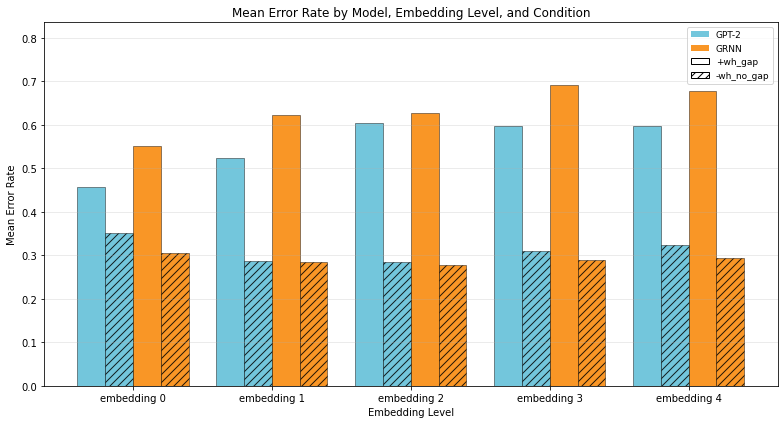

In [13]:
plot_error_rate_by_model_embedding_and_condition({
    'GPT-2': gpt2_results,
    'GRNN':  grnn_results,
})